# Диффузионная аппроксимация против точного пуассоновского правдоподобия

$\theta$ -- 2 состояния, $Y$ -- одномерное, наблюдения: непрерывный канал
(снос $Y$, диффузия $0.3\sqrt{Y}$) и считающий (интенсивность $5Y$).

Конфиги `toy_diffusion_approx` и `toy_exact_poisson` отличаются только видом
плотности считающего канала; порождающая модель у них одна, поэтому все
четыре фильтра работают с одной траекторией и одними наблюдениями.

In [1]:
import _bootstrap  # noqa: F401

import numpy as np
import matplotlib.pyplot as plt

from discretized_filter.config import set_config
from discretized_filter.core.smjp import sparse_mc
from discretized_filter.core.filter import Filter
from discretized_filter.utils.grids import to_discrete
from discretized_filter.visualization.plots import plot_theta_background

cfg_exact = set_config('toy_exact_poisson')
cfg = set_config('toy_diffusion_approx')   # активен последним

print(f'N={cfg.N}, M={cfg.M}, K={cfg.K}, '
      f'шагов={cfg.t_net_filtering.shape[0]}, узлов сетки={cfg.M_net.shape[1]}')

N=2, M=1, K=2, шагов=200, узлов сетки=64


In [2]:
theta, y, t = sparse_mc(cfg.p0, cfg.Lambda, cfg.lam, cfg.T, cfg.get_y, cfg.y_intervals)
observations = cfg.get_obs(cfg.t_net_filtering, theta, y, t)

print(f'скачков theta: {len(t)}, '
      f'отсчётов считающего канала: {observations[:, 1].sum():.0f} '
      f'(в среднем {observations[:, 1].mean():.2f} за шаг, макс {observations[:, 1].max():.0f})')

скачков theta: 8, отсчётов считающего канала: 87 (в среднем 0.44 за шаг, макс 4)


In [3]:
def run(config, two_jumps):
    f = Filter(
        config.pi_init, config.pi, config.M_net, config.C,
        config.N, config.Lambda, config.ht, config.delta, config.obs_density,
        n_points=config.n_points, two_jumps=two_jumps,
    )
    est = f.estimate()
    th, yy = [est[0]], [est[1]]
    for obs in observations:
        f.update(obs)
        est = f.estimate()
        th.append(est[0])
        yy.append(est[1])
    return np.array(th), np.array(yy)


runs = {}
for label, config in [('аппроксимация', cfg), ('точный', cfg_exact)]:
    for r in (1, 2):
        runs[(label, r)] = run(config, two_jumps=(r == 2))

In [4]:
dtheta = to_discrete(
    np.vstack([np.int64(theta == i) for i in range(cfg.N)]).T, t, cfg.T, cfg.ht
)
dY = to_discrete(y, t, cfg.T, cfg.ht)
n = dtheta.shape[0]

print(f'{"фильтр":<26} {"RMSE theta":>11} {"RMSE Y":>9}')
for (label, r), (th, yy) in runs.items():
    rt = np.sqrt(((dtheta - th[:n]) ** 2).mean())
    ry = np.sqrt(((dY - yy[:n]) ** 2).mean())
    print(f'{label + ", " + str(r) + " скач.":<26} {rt:11.4f} {ry:9.4f}')

фильтр                      RMSE theta    RMSE Y
аппроксимация, 1 скач.          0.4079    0.4748
аппроксимация, 2 скач.          0.4067    0.4757
точный, 1 скач.                 0.3815    0.4713
точный, 2 скач.                 0.3796    0.4712


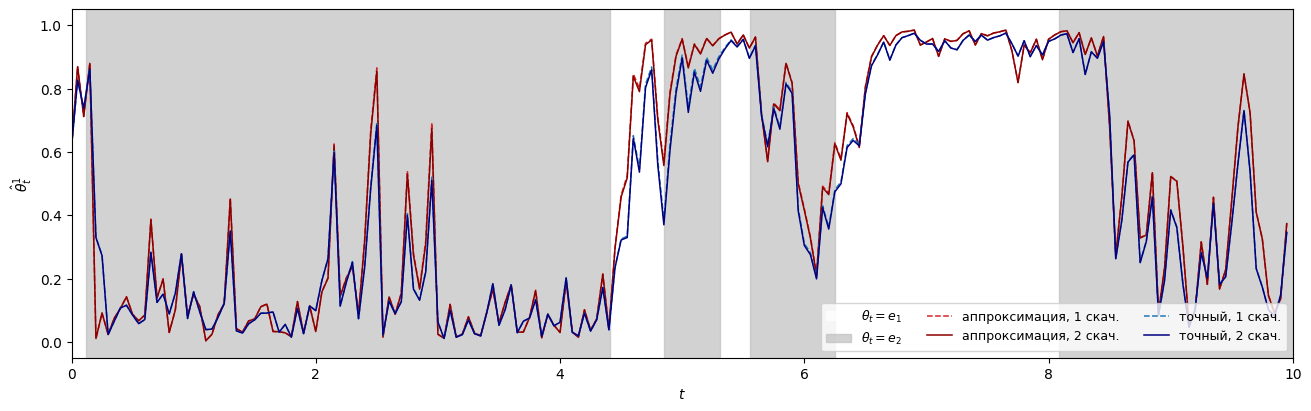

In [5]:
styles = {
    ('аппроксимация', 1): dict(color='tab:red',  ls='--', lw=1.1),
    ('аппроксимация', 2): dict(color='darkred',  ls='-',  lw=1.1),
    ('точный',        1): dict(color='tab:blue', ls='--', lw=1.1),
    ('точный',        2): dict(color='navy',     ls='-',  lw=1.1),
}

fig, ax = plt.subplots(figsize=(13, 4), layout='constrained')
plot_theta_background(
    ax, theta, t, ['$\\theta_t = e_1$', '$\\theta_t = e_2$'],
    ['white', 'silver'], 1, alpha=0.7
)
for k, (th, _) in runs.items():
    ax.plot(cfg.t_net_filtering, th[:, 0], label=f'{k[0]}, {k[1]} скач.', **styles[k])
ax.set(xlabel='$t$', ylabel='$\\hat{\\theta}^1_t$',
       xlim=(0, cfg.T), ylim=(-0.05, 1.05))
ax.legend(ncol=3, fontsize=9, loc='lower right')
plt.show()

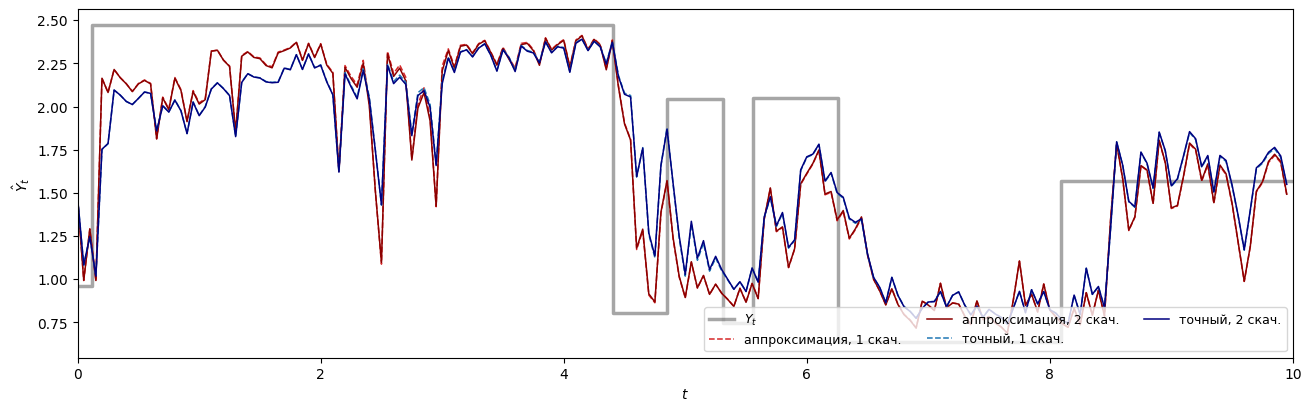

In [6]:
fig, ax = plt.subplots(figsize=(13, 4), layout='constrained')
ax.step([0] + list(t), [y[0, 0]] + list(y[:, 0]),
        where='pre', color='k', lw=2.5, alpha=0.35, label='$Y_t$')
for k, (_, yy) in runs.items():
    ax.plot(cfg.t_net_filtering, yy[:n, 0], label=f'{k[0]}, {k[1]} скач.', **styles[k])
ax.set(xlabel='$t$', ylabel='$\\hat{Y}_t$', xlim=(0, cfg.T))
ax.legend(ncol=3, fontsize=9, loc='lower right')
plt.show()

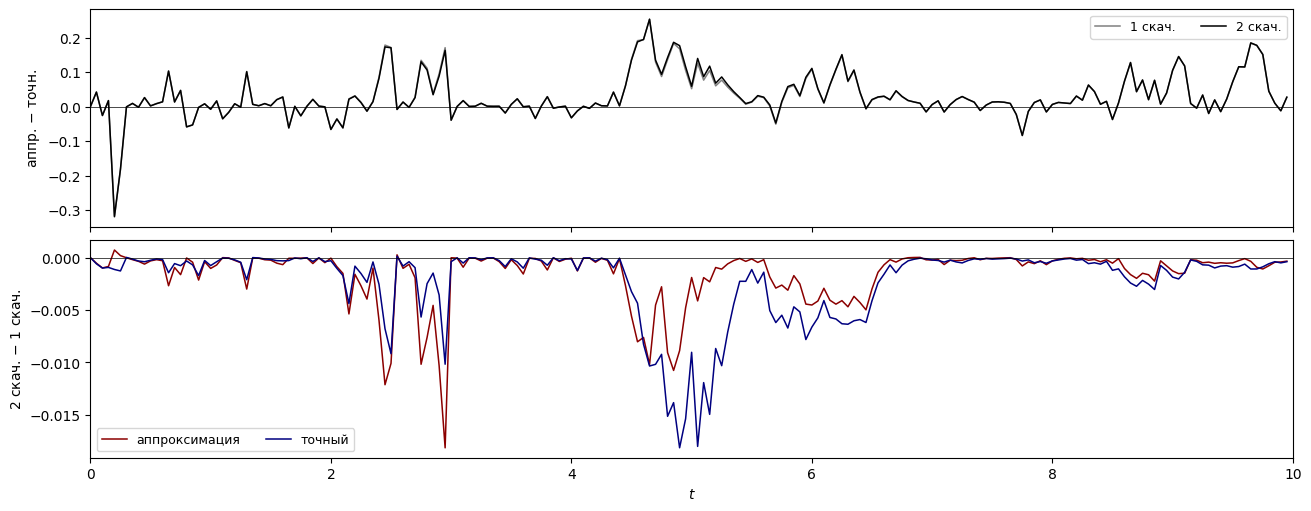

макс |аппр. - точн.|     = 0.3206
макс |2 скач. - 1 скач.| = 0.0182
h*lambda_max = 0.050, P(скачков >= 2 за шаг) ~ 1.25e-03


In [7]:
# два эффекта по отдельности: цена аппроксимации и вклад второго скачка
fig, ax = plt.subplots(2, figsize=(13, 5), layout='constrained', sharex=True)

for r, color in [(1, 'gray'), (2, 'k')]:
    d = runs[('аппроксимация', r)][0][:, 0] - runs[('точный', r)][0][:, 0]
    ax[0].plot(cfg.t_net_filtering, d, color=color, lw=1.1, label=f'{r} скач.')
ax[0].set(ylabel='аппр. $-$ точн.')

for label, color in [('аппроксимация', 'darkred'), ('точный', 'navy')]:
    d = runs[(label, 2)][0][:, 0] - runs[(label, 1)][0][:, 0]
    ax[1].plot(cfg.t_net_filtering, d, color=color, lw=1.1, label=label)
ax[1].set(xlabel='$t$', ylabel='2 скач. $-$ 1 скач.', xlim=(0, cfg.T))

for a in ax:
    a.axhline(0, color='k', lw=0.5)
    a.legend(fontsize=9, ncol=2)
plt.show()

d_appr = max(np.abs(runs[('аппроксимация', r)][0][:, 0] - runs[('точный', r)][0][:, 0]).max()
             for r in (1, 2))
d_jump = max(np.abs(runs[(l, 2)][0][:, 0] - runs[(l, 1)][0][:, 0]).max()
             for l in ('аппроксимация', 'точный'))
hl = cfg.ht * np.abs(cfg.lam).max()

print(f'макс |аппр. - точн.|     = {d_appr:.4f}')
print(f'макс |2 скач. - 1 скач.| = {d_jump:.4f}')
print(f'h*lambda_max = {hl:.3f}, P(скачков >= 2 за шаг) ~ {hl ** 2 / 2:.2e}')